In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/data/heart_cleaned.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Lifestyle Analysis
## Overview
This section examines five key behavioral variables: smoking status, e-cigarette usage, alcohol consumption, physical activity, and sleep hours. We explore how each factor individually, and in combination, relates to the health disease.

Questions we want to answer:

1. **Smoking Status** What is the breakdown of smokers in the dataset, and which smoking group has the highest heart attack rate?

2. **E-Cigarette & Combined Tobacco Use** Do e-cigarette users have higher heart attack rates than non-users and what about those people who both smoke and vape?

3. **Which Lifestyle Factor Matters Most?** Accross the various lifestyle factors, which one has the biggest gap in heart attack rate between healthy and unhealthy groups?

4. **Lifestyle Profile Comparison** What do the lifestyle habits of someone who had a heart attack look like compared to someone who didn't?

5. **Stacking Bad Habits** Does having more unhealthy lifestyle behaviors at the same time increase heart attack risk?

6. **Geographic Patterns** Which states have the highest rates of unhealthy lifestyle behaviors among people who had a heart attack?

## Q1: Smoking Status & Heart Attack Rate

**Question:** What is the breakdown of smokers in the dataset and which smoking group has the highest heart attack rate?

In [63]:
# Filtering the data
q1_data = data[['SmokerStatus', 'HadHeartAttack']]

# Counting how many people are in each group
smoke_counts = q1_data['SmokerStatus'].value_counts().reset_index()
smoke_counts.columns = ['SmokerStatus', 'Count']

# Shortened labels since the original names are too long for graphs
label_map = {
    'Current smoker - now smokes every day': 'Daily Smoker',
    'Current smoker - now smokes some days': 'Some Days',
    'Former smoker': 'Former',
    'Never smoked': 'Never',
    'Unknown': 'Unknown'
}

# Dataframe for smokers by group
smoke_counts

,SmokerStatus,Count
0,Never smoked,244613
1,Former smoker,113009
2,Current smoker - now smokes every day,35682
3,Unknown,34941
4,Current smoker - now smokes some days,13822


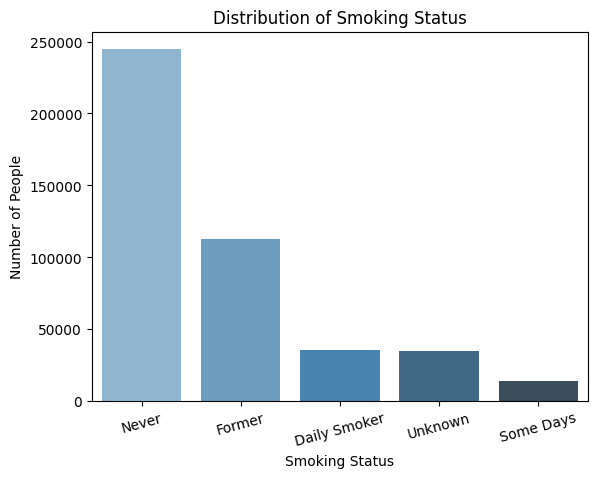

In [57]:
# Bar plot the distribution of smoking status
sns.barplot(data=smoke_counts, x='SmokerStatus', y='Count', hue = 'SmokerStatus', palette='Blues_d')

# Labels
labels = smoke_counts['SmokerStatus'].map(label_map)

plt.title('Distribution of Smoking Status')
plt.xlabel("Smoking Status")
plt.ylabel("Number of People")

plt.xticks(ticks=range(len(smoke_counts)), labels=labels, rotation=15)

plt.show()

In [60]:
# Calculating the heart attack rate for each smoking group
heart_attack_rate = q1_data.groupby('SmokerStatus')['HadHeartAttack'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()

heart_attack_rate.columns = ['SmokerStatus', 'HeartAttackRate']
heart_attack_rate = heart_attack_rate.sort_values('HeartAttackRate', ascending=False).reset_index(drop=True)

# Heart Attack rate per smoker status
heart_attack_rate

,SmokerStatus,HeartAttackRate
0,Current smoker - now smokes every day,8.906451
1,Former smoker,8.639135
2,Current smoker - now smokes some days,7.075676
3,Unknown,5.391946
4,Never smoked,3.803968


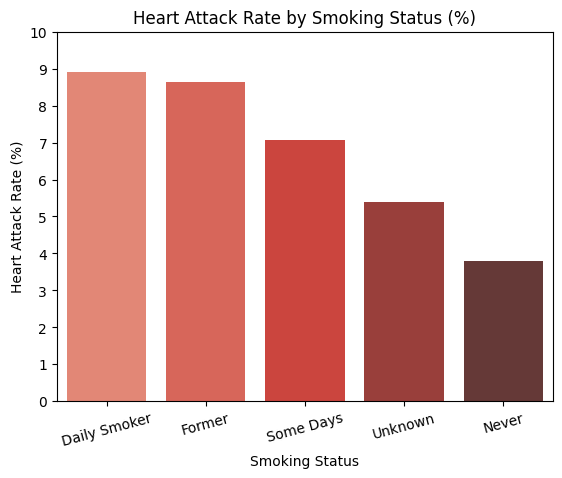

In [32]:
# Bar plot for heart attack rate by smoking status
sns.barplot(data=heart_attack_rate, x='SmokerStatus', y='HeartAttackRate', hue = 'SmokerStatus', palette='Reds_d')

# Labels
plt.title('Heart Attack Rate by Smoking Status (%)')
plt.xlabel('Smoking Status')
plt.ylabel('Heart Attack Rate (%)')

labels = heart_attack_rate['SmokerStatus'].map(label_map)
plt.xticks(ticks=range(len(heart_attack_rate)), labels=labels, rotation=15)
plt.yticks(range(0, 11, 1))

plt.show()

In [64]:
# Function to combine some of the age groups together more
def group_age(age):

  # Age groups from the orginal dataset
  young = ['Age 18 to 24', 'Age 25 to 29', 'Age 30 to 34', 'Age 35 to 39']
  middle_age = ['Age 40 to 44', 'Age 45 to 49', 'Age 50 to 54', 'Age 55 to 59']
  older = ['Age 60 to 64', 'Age 65 to 69', 'Age 70 to 74', 'Age 75 to 79', 'Age 80 or older']

  if age in young:
    return 'Young (18-39)'
  elif age in middle_age:
    return 'Middle (40-59)'
  elif age in older:
    return 'Older (60+)'
  else:
    return 'Unknown'

# Re-classifying the groups
data['AgeGroup'] = data['AgeCategory'].apply(group_age)

# Calculating heart attack rates by smoking status and age group
age_smoke_rate = data.groupby(['SmokerStatus', 'AgeGroup'])['HadHeartAttack'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()

age_smoke_rate.columns = ['SmokerStatus', 'AgeGroup', 'HeartAttackRate']
age_order = ['Young (18-39)', 'Middle (40-59)', 'Older (60+)', 'Unknown']

# Heart Attack rates by smoking status and age
age_smoke_rate.pivot(index='SmokerStatus', columns='AgeGroup', values='HeartAttackRate').round(2)[age_order]

AgeGroup,Young (18-39),Middle (40-59),Older (60+),Unknown
SmokerStatus,,,,
Current smoker - now smokes every day,2.62,6.81,14.53,4.41
Current smoker - now smokes some days,1.24,6.39,13.17,6.37
Former smoker,0.91,4.28,12.33,7.45
Never smoked,0.44,2.13,7.21,2.98
Unknown,0.81,3.49,9.57,3.70


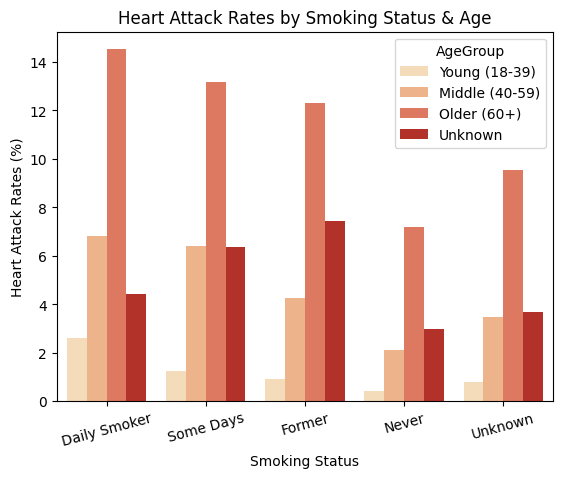

In [65]:
# Bar plot showing heart attack rates by smoking status, broken down by age group
sns.barplot(data=age_smoke_rate, x='SmokerStatus', y='HeartAttackRate', hue='AgeGroup',
            palette='OrRd',
            hue_order=age_order)
# Labels
plt.title("Heart Attack Rates by Smoking Status & Age")
plt.xlabel("Smoking Status")
plt.ylabel("Heart Attack Rates (%)")

x_labels = age_smoke_rate['SmokerStatus'].unique()
labels = pd.Series(x_labels).map(label_map)
plt.xticks(ticks=range(len(x_labels)), labels=labels, rotation=15)

plt.show()

**Answer:** Looking at the data, daily smokers have the highest heart attack rate at around 8.9%, closely followed by former smokers at 8.64%. On the other end, individuals who have never smoked, had the lowest heart attack rate at 3.8%.

## Q2: E-cigarette usage